# Carga de Datos
Cargando la base de datos `casen_2024.parquet` para comenzar el proceso de ETL.

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Cargar los datos (solo las columnas necesarias para no saturar la memoria)
# Si ya tenías el df cargado, puedes saltar esta línea y usar tu df
df = pd.read_parquet('../Data/casen_2024.parquet', columns=['cinef13_area', 'ytrabajocor', 'activ'])


## Análisis de Brecha Salarial por Género y Área de Estudio
A continuación se genera un gráfico interactivo estilo **Dumbbell Plot**, donde se puede observar la diferencia de sueldo promedio (hombres y mujeres) para cada área de estudio. El tamaño de cada punto representa proporcionalmente el **tamaño de la muestra** en esa categoría.

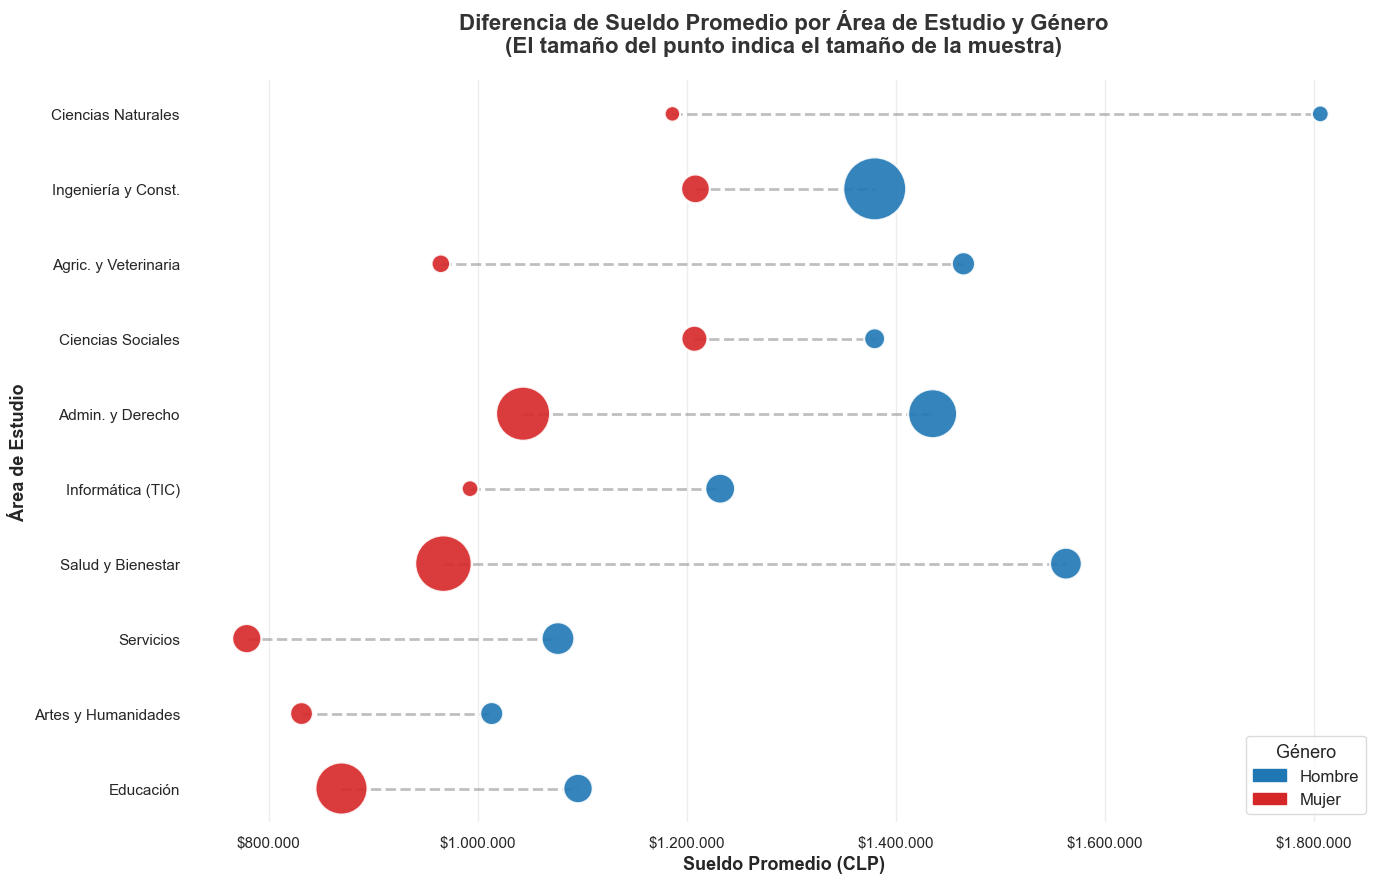

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches

# 1. Cargar datos
df = pd.read_parquet('../Data/casen_2024.parquet', columns=['cinef13_area', 'sexo', 'ytrabajocor'])

# Filtrar valores nulos o inválidos (-88, -99, etc.)
df = df.dropna(subset=['cinef13_area', 'sexo', 'ytrabajocor'])
df = df[df['cinef13_area'] >= 0]
df = df[df['sexo'].isin([1, 2])]

# Mapear áreas usando el diccionario oficial CORREGIDO de Casen 2024 (Anexo 3)
cine_map = {
    1.0: 'Salud y Bienestar',
    2.0: 'Ingeniería y Const.',
    3.0: 'Educación',
    4.0: 'Servicios',
    5.0: 'Admin. y Derecho',
    6.0: 'Ciencias Sociales',
    7.0: 'Ciencias Naturales',
    8.0: 'Agric. y Veterinaria',
    9.0: 'Informática (TIC)',
    10.0: 'Artes y Humanidades',
    11.0: 'Cs. Básicas (Doc.)'
}
df['area_label'] = df['cinef13_area'].map(cine_map)
df['genero_label'] = df['sexo'].map({1: 'Hombre', 2: 'Mujer'})

# Filtrar áreas que no mapearon
df = df.dropna(subset=['area_label'])

# Agrupar y calcular estadísticas: Media y Tamaño de muestra (count)
stats = df.groupby(['area_label', 'genero_label'], as_index=False)['ytrabajocor'].agg(
    promedio='mean',
    tamano='count'
)

# Para un gráfico ordenado, calculamos el promedio general de sueldo por área
area_order = df.groupby('area_label')['ytrabajocor'].mean().sort_values(ascending=True).index
stats['area_label'] = pd.Categorical(stats['area_label'], categories=area_order, ordered=True)
stats = stats.sort_values('area_label')

# 2. Visualización: Dumbbell Plot
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 9))

# Dibujar las líneas grises que conectan a hombres y mujeres
for area in area_order:
    area_data = stats[stats['area_label'] == area]
    if len(area_data) == 2:
        val_h = area_data[area_data['genero_label'] == 'Hombre']['promedio'].values[0]
        val_m = area_data[area_data['genero_label'] == 'Mujer']['promedio'].values[0]
        ax.plot([val_m, val_h], [area, area], color='gray', zorder=1, alpha=0.5, linestyle='--', linewidth=2)

# Configurar factor de tamaño para los puntos
size_factor = 2000 / stats['tamano'].max()

# Colores solicitados: Azul (Hombres), Rojo (Mujeres)
colores = {'Hombre': '#1f77b4', 'Mujer': '#d62728'} 

# Dibujar los puntos
for genero, color in colores.items():
    genero_data = stats[stats['genero_label'] == genero]
    
    # Puntos con tamaño proporcional a la muestra
    ax.scatter(
        genero_data['promedio'], 
        genero_data['area_label'], 
        s=genero_data['tamano'] * size_factor + 50, # +50 asegura un tamaño mínimo
        color=color, 
        label=genero,
        alpha=0.9,
        zorder=3,
        edgecolors='white',
        linewidth=1.5
    )

# Títulos y etiquetas
ax.set_title('Diferencia de Sueldo Promedio por Área de Estudio y Género\n(El tamaño del punto indica el tamaño de la muestra)', fontsize=16, pad=20, fontweight='bold', color='#333333')
ax.set_xlabel('Sueldo Promedio (CLP)', fontsize=13, fontweight='bold')
ax.set_ylabel('Área de Estudio', fontsize=13, fontweight='bold')
ax.grid(axis='x', linestyle='-', alpha=0.4, color='lightgray')
ax.grid(axis='y', alpha=0)

# Ocultar los bordes del gráfico
sns.despine(left=True, bottom=True)

# Formatear el eje X como moneda
formatter = ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}'.replace(',', '.'))
ax.xaxis.set_major_formatter(formatter)

# Personalizar Leyenda (Cuadrados de colores)
legend_elements = [
    mpatches.Patch(color=colores['Hombre'], label='Hombre'),
    mpatches.Patch(color=colores['Mujer'], label='Mujer')
]
legend = ax.legend(handles=legend_elements, title='Género', loc='lower right', frameon=True, fontsize=12, title_fontsize=13)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('lightgray')

plt.tight_layout()
plt.show()


## Exploración Profunda: Top 5 Carreras por Área de Estudio
A continuación exploramos cuáles son las carreras específicas más frecuentes dentro de cada macro-área (como *Salud y Bienestar* vs *Ciencias Naturales*) para comprender mejor la composición interna y explicar las posibles brechas salariales y tamaños de muestra.

In [8]:
# 3. Top 5 carreras con mayor frecuencia por Área de Estudio
import pandas as pd

# Cargar datos de áreas y el nombre de la carrera (columna e7)
df_carreras = pd.read_parquet('../Data/casen_2024.parquet', columns=['cinef13_area', 'e7'])

# Limpiar vacíos
df_carreras = df_carreras.dropna(subset=['cinef13_area', 'e7'])
df_carreras = df_carreras[df_carreras['cinef13_area'] >= 0]
df_carreras = df_carreras[df_carreras['e7'].str.strip() != '']

# Mapear áreas usando el diccionario oficial CORREGIDO
cine_map = {
    1.0: 'Salud y Bienestar',
    2.0: 'Ingeniería y Const.',
    3.0: 'Educación',
    4.0: 'Servicios',
    5.0: 'Admin. y Derecho',
    6.0: 'Ciencias Sociales',
    7.0: 'Ciencias Naturales',
    8.0: 'Agric. y Veterinaria',
    9.0: 'Informática (TIC)',
    10.0: 'Artes y Humanidades',
    11.0: 'Cs. Básicas (Doc.)'
}
df_carreras['area_label'] = df_carreras['cinef13_area'].map(cine_map)
df_carreras = df_carreras.dropna(subset=['area_label'])

# Normalizar el nombre de la carrera a formato Título para agrupar mejor
df_carreras['carrera'] = df_carreras['e7'].str.strip().str.title()

# Obtener frecuencias
frecuencias = df_carreras.groupby(['area_label', 'carrera']).size().reset_index(name='frecuencia')
frecuencias = frecuencias.sort_values(['area_label', 'frecuencia'], ascending=[True, False])

# Mostrar el Top 5 para cada área
print("=" * 60)
print("TOP 5 CARRERAS MÁS FRECUENTES POR ÁREA DE ESTUDIO")
print("=" * 60)

for area in cine_map.values():
    top5 = frecuencias[frecuencias['area_label'] == area].head(5)
    if not top5.empty:
        print(f"\n--- {area.upper()} ---")
        for i, row in enumerate(top5.itertuples(), 1):
            print(f"{i}. {row.carrera} ({row.frecuencia} encuestados)")


TOP 5 CARRERAS MÁS FRECUENTES POR ÁREA DE ESTUDIO

--- SALUD Y BIENESTAR ---
1. Técnico(A) En Enfermería (1664 encuestados)
2. Enfermería (1381 encuestados)
3. Trabajo Social (941 encuestados)
4. Kinesiología (620 encuestados)
5. Medicina (492 encuestados)

--- INGENIERÍA Y CONST. ---
1. Ingeniería Civil Industrial (788 encuestados)
2. Arquitectura (502 encuestados)
3. Ingeniería Civil (432 encuestados)
4. Construcción Civil (355 encuestados)
5. Ingeniería En Construcción (340 encuestados)

--- EDUCACIÓN ---
1. Educación Parvularia (421 encuestados)
2. Educador(A) De Párvulos (384 encuestados)
3. Pedagogía En Educación Física (384 encuestados)
4. Pedagogía En Inglés (358 encuestados)
5. Pedagogía En Educación Básica (281 encuestados)

--- SERVICIOS ---
1. Ingeniería En Prevención De Riesgos (482 encuestados)
2. Gastronomía (344 encuestados)
3. Prevención De Riesgos (246 encuestados)
4. Gastronomía Internacional (202 encuestados)
5. Técnico(A) En Prevención De Riesgos (200 encuestados)
